In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.io import savemat
import os
from pathlib import Path
from sklearn.decomposition import PCA
from collections import Counter
from sklearn.preprocessing import StandardScaler
from utils import load_data, corr_x_y
%matplotlib inline

In [2]:
data_dir = Path('./data2')
BRCA_path = Path("./BRCA.mat")
BRCA_data = sio.loadmat(BRCA_path)
print(BRCA_data.keys())
gene_expression = BRCA_data['BRCA_Gene_Expression'].T
print(gene_expression.shape)
methy_expression = BRCA_data['BRCA_Methy_Expression'].T
print(methy_expression.shape)
mirna_expression = BRCA_data['BRCA_Mirna_Expression'].T
print(mirna_expression.shape)
labels = BRCA_data['BRCA_clinicalMatrix'].flatten()
print(labels.shape)
indexes = BRCA_data['BRCA_indexes'].flatten()
print(indexes.shape)

dict_keys(['__header__', '__version__', '__globals__', 'BRCA_Gene_Expression', 'BRCA_Methy_Expression', 'BRCA_Mirna_Expression', 'BRCA_clinicalMatrix', 'BRCA_indexes'])
(646, 20531)
(646, 5000)
(646, 1046)
(646,)
(646,)


In [4]:
index_gene_dict = {}
index_methy_dict = {}
index_mirna_dict = {}
label_dict = {}
for idx in indexes:
    idx = int(idx)
    index_gene_dict[idx] = len(index_gene_dict)
    index_methy_dict[idx] = len(index_methy_dict)
    index_mirna_dict[idx] = len(index_mirna_dict)
    label_dict[idx] = labels[idx]
print(index_gene_dict)
print(index_methy_dict)
print(index_mirna_dict)
print(label_dict)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 83: 83, 84: 84, 85: 85, 86: 86, 87: 87, 88: 88, 89: 89, 90: 90, 91: 91, 92: 92, 93: 93, 94: 94, 95: 95, 96: 96, 97: 97, 98: 98, 99: 99, 100: 100, 101: 101, 102: 102, 103: 103, 104: 104, 105: 105, 106: 106, 107: 107, 108: 108, 109: 109, 110: 110, 111: 111, 112: 112, 113: 113, 114: 114, 115: 115, 116: 116, 117: 117, 118: 118, 119: 119, 120: 120, 121: 121,

In [43]:
def corr_x_y(x: np.ndarray, y: np.ndarray, eps=1e-8):
    x = x - np.mean(x, axis=-1, keepdims=True)
    y = y - np.mean(y, axis=-1, keepdims=True)
    lxy = np.dot(x, y.T)
    lxx = np.diag(np.dot(x, x.T)).reshape((-1, 1))
    lyy = np.diag(np.dot(y, y.T)).reshape((1, -1))
    corr = lxy / (np.dot(np.sqrt(lxx), np.sqrt(lyy)) + eps)
    return corr

In [26]:
gene_expression_scaled = StandardScaler().fit_transform(gene_expression)
pca = PCA(n_components=0.95)
gene_expression_pca = pca.fit_transform(gene_expression_scaled)
print(gene_expression_pca.shape)

methy_expression_scaled = StandardScaler().fit_transform(methy_expression)
pca = PCA(n_components=0.95)
methy_expression_pca = pca.fit_transform(methy_expression_scaled)
print(methy_expression_pca.shape)

mirna_expression_scaled = StandardScaler().fit_transform(mirna_expression)
pca = PCA(n_components=0.95)
mirna_expression_pca = pca.fit_transform(mirna_expression_scaled)
print(mirna_expression_pca.shape)

(646, 435)
(646, 405)
(646, 305)


<Axes: >

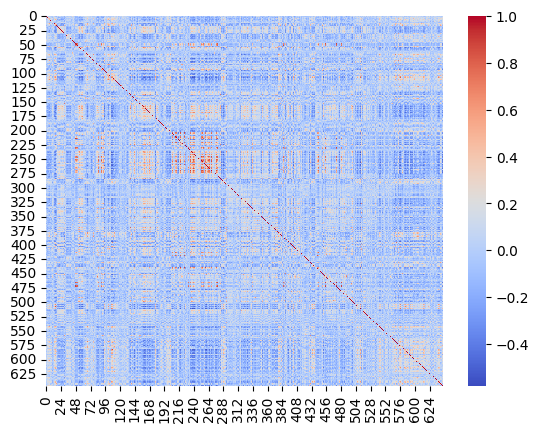

In [44]:
corr_gene = corr_x_y(gene_expression_pca, gene_expression_pca)
corr_methy = corr_x_y(methy_expression_pca, methy_expression_pca)
corr_mirna = corr_x_y(mirna_expression_pca, mirna_expression_pca)
sns.heatmap(corr_gene, cmap='coolwarm')

In [61]:
indexes_07 = np.where(np.abs(corr_gene) > 0.7)
pair_count = list(zip(indexes_07[0], indexes_07[1]))
print(len(pair_count))
print(pair_count[:10])
corr_scaled_gene = corr_x_y(gene_expression_scaled, gene_expression_scaled)
indexes_07_scaled = np.where(np.abs(corr_scaled_gene) > 0.7)
pair_count_scaled = list(zip(indexes_07_scaled[0], indexes_07_scaled[1]))
print(len(pair_count_scaled))
print(pair_count_scaled[:10])
len(set(pair_count) | set(pair_count_scaled))

1682
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]
1016
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]


1682

In [67]:
indexes_07 = np.where(np.abs(corr_methy) > 0.75)
pair_count = list(zip(indexes_07[0], indexes_07[1]))
print(len(pair_count))
print(pair_count[:10])
corr_scaled_methy = corr_x_y(methy_expression_scaled, methy_expression_scaled)
indexes_07_scaled = np.where(np.abs(corr_scaled_methy) > 0.75)
pair_count_scaled = list(zip(indexes_07_scaled[0], indexes_07_scaled[1]))
print(len(pair_count_scaled))
print(pair_count_scaled[:10])
len(set(pair_count) | set(pair_count_scaled))

6240
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(7), np.int64(96)), (np.int64(7), np.int64(186))]
4122
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]


6240

In [9]:
data_edges_95_dir = os.path.join(data_dir, 'PCA_BRCA_95')
edges_95_gene_path = os.path.join(data_edges_95_dir, 'edges_gene_brca.csv')
edges_95_methy_path = os.path.join(data_edges_95_dir, 'edges_methy_brca.csv')
edges_95_mirna_path = os.path.join(data_edges_95_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_95_gene_path, edges_95_methy_path, edges_95_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\PCA_BRCA_95\\edges_gene_brca.csv': 2022, 'data2\\PCA_BRCA_95\\edges_methy_brca.csv': 1056, 'data2\\PCA_BRCA_95\\edges_mirna_brca.csv': 1884}
Invalid edges count: {'data2\\PCA_BRCA_95\\edges_gene_brca.csv': 424, 'data2\\PCA_BRCA_95\\edges_methy_brca.csv': 286, 'data2\\PCA_BRCA_95\\edges_mirna_brca.csv': 606}


In [11]:
data_edges_97_dir = os.path.join(data_dir, 'PCA_BRCA_97')
edges_97_gene_path = os.path.join(data_edges_97_dir, 'edges_gene_brca.csv')
edges_97_methy_path = os.path.join(data_edges_97_dir, 'edges_methy_brca.csv')
edges_97_mirna_path = os.path.join(data_edges_97_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_97_gene_path, edges_97_methy_path, edges_97_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\PCA_BRCA_97\\edges_gene_brca.csv': 1888, 'data2\\PCA_BRCA_97\\edges_methy_brca.csv': 976, 'data2\\PCA_BRCA_97\\edges_mirna_brca.csv': 1678}
Invalid edges count: {'data2\\PCA_BRCA_97\\edges_gene_brca.csv': 382, 'data2\\PCA_BRCA_97\\edges_methy_brca.csv': 246, 'data2\\PCA_BRCA_97\\edges_mirna_brca.csv': 520}


In [12]:
data_edges_baseline_dir = os.path.join(data_dir, 'BRCA')
edges_baseline_gene_path = os.path.join(data_edges_baseline_dir, 'edges_gene_brca.csv')
edges_baseline_methy_path = os.path.join(data_edges_baseline_dir, 'edges_methy_brca.csv')
edges_baseline_mirna_path = os.path.join(data_edges_baseline_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_baseline_gene_path, edges_baseline_methy_path, edges_baseline_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\BRCA\\edges_gene_brca.csv': 758, 'data2\\BRCA\\edges_methy_brca.csv': 1820, 'data2\\BRCA\\edges_mirna_brca.csv': 8260}
Invalid edges count: {'data2\\BRCA\\edges_gene_brca.csv': 258, 'data2\\BRCA\\edges_methy_brca.csv': 2302, 'data2\\BRCA\\edges_mirna_brca.csv': 3608}


In [24]:
data_brca_5_labels_dir = "./data2/BRCA_v2"
labels_path = os.path.join(data_brca_5_labels_dir, "labels.csv")
BRCA_gene_path = os.path.join(data_brca_5_labels_dir, "BRCA_mRNA_top.csv")
BRCA_miRNA_path = os.path.join(data_brca_5_labels_dir, "BRCA_miRNA_top.csv")
BRCA_Methy_path = os.path.join(data_brca_5_labels_dir, "BRCA_Methy_top.csv")
gene_data = pd.read_csv(BRCA_gene_path, index_col=0).T
miRNA_data = pd.read_csv(BRCA_miRNA_path, index_col=0).T
methy_data = pd.read_csv(BRCA_Methy_path, index_col=0).T
labels = pd.read_csv(labels_path).values.flatten()
indexes = gene_data.index.values
print(gene_data.shape)
print(miRNA_data.shape)
print(methy_data.shape)
print(labels.shape)
print(indexes.shape)

(671, 5000)
(671, 200)
(671, 5000)
(671,)
(671,)


In [25]:
assert set(methy_data.index) == set(gene_data.index) == set(miRNA_data.index) == set(indexes)
indexes_gene_dict = {idx: i for i, idx in enumerate(indexes)}
gene_data.index = gene_data.index.map(indexes_gene_dict)
methy_data.index = methy_data.index.map(indexes_gene_dict)
miRNA_data.index = miRNA_data.index.map(indexes_gene_dict)

In [27]:
save_mat_path = "./BRCA_v5_labels.mat"
sio.savemat(save_mat_path, {
    'BRCA_Gene_Expression': gene_data.values.T,
    'BRCA_Methy_Expression': methy_data.values.T,
    'BRCA_Mirna_Expression': miRNA_data.values.T,
    'BRCA_clinicalMatrix': labels.reshape(-1, 1),
    'BRCA_indexes': miRNA_data.index.values.reshape(-1, 1),
})

In [7]:
def convert_csv_to_mat(data_dir, name_subtype="BRCA"):
    labels_path = os.path.join(data_dir, "labels.csv")
    gene_path = os.path.join(data_dir, f"{name_subtype}_mRNA_top.csv")
    miRNA_path = os.path.join(data_dir, f"{name_subtype}_miRNA_top.csv")
    methy_path = os.path.join(data_dir, f"{name_subtype}_Methy_top.csv")
    
    gene_data = pd.read_csv(gene_path, index_col=0).T
    miRNA_data = pd.read_csv(miRNA_path, index_col=0).T
    methy_data = pd.read_csv(methy_path, index_col=0).T
    labels = pd.read_csv(labels_path).values.flatten()
    indexes = gene_data.index.values
    gene_data = gene_data.loc[:, (gene_data != 0).any(axis=0)]
    miRNA_data = miRNA_data.loc[:, (miRNA_data != 0).any(axis=0)]
    methy_data = methy_data.loc[:, (methy_data != 0).any(axis=0)]
    gene_data = gene_data.dropna(axis=1)
    miRNA_data = miRNA_data.dropna(axis=1)
    methy_data = methy_data.dropna(axis=1)
    assert set(methy_data.index) == set(gene_data.index) == set(miRNA_data.index) == set(indexes)
    indexes_gene_dict = {idx: i for i, idx in enumerate(indexes)}
    gene_data.index = gene_data.index.map(indexes_gene_dict)
    methy_data.index = methy_data.index.map(indexes_gene_dict)
    miRNA_data.index = miRNA_data.index.map(indexes_gene_dict)
    
    save_mat_path = os.path.join(data_dir, f"{name_subtype}.mat")
    sio.savemat(save_mat_path, {
        f'{name_subtype}_Gene_Expression': gene_data.values.T,
        f'{name_subtype}_Methy_Expression': methy_data.values.T,
        f'{name_subtype}_Mirna_Expression': miRNA_data.values.T,
        f'{name_subtype}_clinicalMatrix': labels.reshape(-1, 1),
        f'{name_subtype}_indexes': miRNA_data.index.values.reshape(-1, 1),
    })

In [8]:
lgg_path_dir = "./data2/LGG"
convert_csv_to_mat(lgg_path_dir, name_subtype="LGG")

In [9]:
lgg_path_dir = "./data2/OV"
convert_csv_to_mat(lgg_path_dir, name_subtype="OV")

In [ ]:
PCA_GBM_dir = "./data2/PCA_GBM"
edges_gene_path = os.path.join(PCA_GBM_dir, 'edges_gene_gbm.csv')
edges_methy_path = os.path.join(PCA_GBM_dir, 'edges_methy_gbm.csv')
edges_mirna_path = os.path.join(PCA_GBM_dir, 'edges_mirna_gbm.csv')


In [7]:
BRCA_v5_path_dir = "./data2/BRCA_v2"
labels_path = os.path.join(BRCA_v5_path_dir, "labels.csv")
df = pd.read_csv(labels_path, header=0)
values = df.values.reshape(-1).tolist()
Counter(values)
OV_path_dir = "./data2/OV"
labels_path = os.path.join(OV_path_dir, "labels.csv")
df = pd.read_csv(labels_path, header=0)
values = df.values.reshape(-1).tolist()
Counter(values)
LGG_path_dir = "./data2/LGG"
labels_path = os.path.join(LGG_path_dir, "labels.csv")
df = pd.read_csv(labels_path, header=0)
values = df.values.reshape(-1).tolist()
Counter(values)

Counter({1: 125, 0: 76, 2: 46})

In [44]:
def get_percentile_threshold(
    features: np.ndarray,
    type: str = "BRCA",
    method: str = 'corr',
    threshold_pct: float = 97.0,
):    
    scaler = StandardScaler()
    normal_features = scaler.fit_transform(features)


    sim_fn = {
        'corr':        lambda x: np.abs(corr_x_y(x, x)),
    }.get(method)
    if sim_fn is None:
        raise ValueError(f"Unknown method: {method!r}. "
                         f"Choose from: corr, cos, euclidean, mahalanobis")
    
    z_raw = sim_fn(normal_features)
    z_fused = np.clip(z_raw, 0.0, 1.0)
    off_diag = z_fused[~np.eye(z_fused.shape[0], dtype=bool)]

    threshhold = np.percentile(off_diag, threshold_pct)
    print("Percentile threshold (%.1f%%): %.4f", threshold_pct, threshhold)
    return z_fused

def ratio_same_label_edges(type='BRCA',data_path='BRCA.mat', data_edges_dir='./data2/PER_BRCA_'):
    edge_gene_path = os.path.join(data_edges_dir, f'edges_gene_{type.lower()}.csv')
    edge_methy_path = os.path.join(data_edges_dir, f'edges_methy_{type.lower()}.csv')
    edge_mirna_path = os.path.join(data_edges_dir, f'edges_mirna_{type.lower()}.csv')
    features1, features2, features3, labels, indexes = load_data(data_path, type=type)
    with open(edge_gene_path, 'r') as f:
        lines = f.readlines()
        same_label_count = 0
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if node1 != node2 and labels[node1] == labels[node2]:
                same_label_count += 1
        ratio = same_label_count / len(lines)
        print(f"Gene edges with same label ratio: ", ratio)
    with open(edge_methy_path, 'r') as f:
        lines = f.readlines()
        same_label_count = 0
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if node1 != node2 and labels[node1] == labels[node2]:
                same_label_count += 1
        ratio = same_label_count / len(lines)
        print(f"Methylation edges with same label ratio: ", ratio)
    with open(edge_mirna_path, 'r') as f:
        lines = f.readlines()
        same_label_count = 0
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if node1 != node2 and labels[node1] == labels[node2]:
                same_label_count += 1
        ratio = same_label_count / len(lines)
        print(f"MiRNA edges with same label ratio: ", ratio)
    

2026-06-21 08:46:35,308 - INFO - Shape of Gene Expression: (646, 20531)
2026-06-21 08:46:35,308 - INFO - Shape of Methylation Expression: (646, 5000)
2026-06-21 08:46:35,308 - INFO - Shape of miRNA Expression: (646, 1046)
2026-06-21 08:46:35,308 - INFO - Shape of labels: (646,)
2026-06-21 08:46:35,308 - INFO - Shape of indexes: (646,)


Percentile threshold (%.1f%%): %.4f 98.5 0.3722701404793358
Percentile threshold (%.1f%%): %.4f 98.5 0.6120637168935986
Percentile threshold (%.1f%%): %.4f 98 0.27506391005235886
Feature 1: Optimal threshold percentile: 98.5, Similarity value: 0.3722701404793358
Feature 2: Optimal threshold percentile: 98.5, Similarity value: 0.6120637168935986
Feature 3: Optimal threshold percentile: 98.0, Similarity value: 0.27506391005235886


2026-06-21 08:46:37,192 - INFO - Shape of Gene Expression: (646, 20531)
2026-06-21 08:46:37,193 - INFO - Shape of Methylation Expression: (646, 5000)
2026-06-21 08:46:37,194 - INFO - Shape of miRNA Expression: (646, 1046)
2026-06-21 08:46:37,194 - INFO - Shape of labels: (646,)
2026-06-21 08:46:37,194 - INFO - Shape of indexes: (646,)


Gene edges with same label ratio:  0.5365429234338747
Methylation edges with same label ratio:  0.33178654292343385
MiRNA edges with same label ratio:  0.6416481069042316


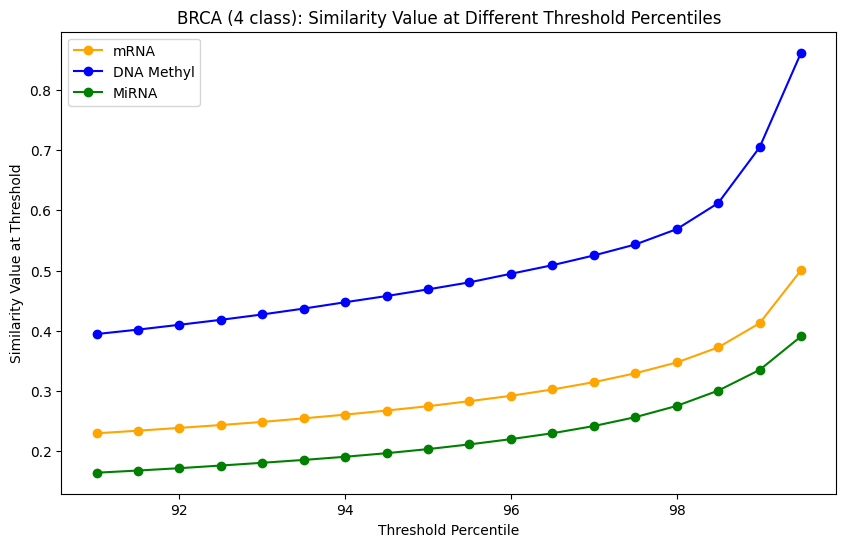

In [58]:
## BRCA
features1, features2, features3, labels, indexes = load_data("BRCA.mat", type="BRCA")
z_fused_fea1 = get_percentile_threshold(features1, type="BRCA", method='corr', threshold_pct=98.5)
z_fused_fea2 = get_percentile_threshold(features2, type="BRCA", method='corr', threshold_pct=98.5)
z_fused_fea3 = get_percentile_threshold(features3, type="BRCA", method='corr', threshold_pct=98)
thresholds = np.arange(91, 100, 0.5)
per_threshold_fea1 = [np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea2 = [np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea3 = [np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold) for threshold in thresholds]
plt.figure(figsize=(10, 6))
plt.plot(thresholds, per_threshold_fea1, label='mRNA', marker='o', color='orange')
plt.plot(thresholds, per_threshold_fea2, label='DNA Methyl', marker='o', color='blue')
plt.plot(thresholds, per_threshold_fea3, label='MiRNA', marker='o', color='green')
plt.xlabel('Threshold Percentile')
plt.ylabel('Similarity Value at Threshold')
plt.legend()
plt.title('BRCA (4 class): Similarity Value at Different Threshold Percentiles')
plt.savefig('./images/BRCA_v4_similarity_thresholds.png', dpi=300)
deltas_fea1 = [abs((per_threshold_fea1[i] - per_threshold_fea1[0]) - (per_threshold_fea1[-1] - per_threshold_fea1[i])) for i in range(1, len(per_threshold_fea1))]
deltas_fea2 = [abs((per_threshold_fea2[i] - per_threshold_fea2[0]) - (per_threshold_fea2[-1] - per_threshold_fea2[i])) for i in range(1, len(per_threshold_fea2))]
deltas_fea3 = [abs((per_threshold_fea3[i] - per_threshold_fea3[0]) - (per_threshold_fea3[-1] - per_threshold_fea3[i])) for i in range(1, len(per_threshold_fea3))]
deltas_fea1_min = np.argmin(deltas_fea1) + 1
threshold_fea1 = thresholds[deltas_fea1_min]
deltas_fea2_min = np.argmin(deltas_fea2) + 1
threshold_fea2 = thresholds[deltas_fea2_min]
deltas_fea3_min = np.argmin(deltas_fea3) + 1
threshold_fea3 = thresholds[deltas_fea3_min]
print(f"Feature 1: Optimal threshold percentile: {threshold_fea1}, Similarity value: {per_threshold_fea1[deltas_fea1_min]}")
print(f"Feature 2: Optimal threshold percentile: {threshold_fea2}, Similarity value: {per_threshold_fea2[deltas_fea2_min]}")
print(f"Feature 3: Optimal threshold percentile: {threshold_fea3}, Similarity value: {per_threshold_fea3[deltas_fea3_min]}")
ratio_same_label_edges(type='BRCA', data_path='BRCA.mat', data_edges_dir='./data2/PER_BRCA_')
# print("Features 1:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold))
# print("Features 2:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold))
# print("Features 3:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ",np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold))

2026-06-21 13:48:17,165 - INFO - Shape of Gene Expression: (248, 12042)
2026-06-21 13:48:17,166 - INFO - Shape of Methylation Expression: (248, 5000)
2026-06-21 13:48:17,166 - INFO - Shape of miRNA Expression: (248, 534)
2026-06-21 13:48:17,167 - INFO - Shape of labels: (248,)
2026-06-21 13:48:17,167 - INFO - Shape of indexes: (248,)


Percentile threshold (%.1f%%): %.4f 97.5 0.38060333479010033
Percentile threshold (%.1f%%): %.4f 98 0.36637774217501806
Percentile threshold (%.1f%%): %.4f 98 0.41595028507729354


2026-06-21 13:48:17,611 - INFO - Shape of Gene Expression: (248, 12042)
2026-06-21 13:48:17,612 - INFO - Shape of Methylation Expression: (248, 5000)
2026-06-21 13:48:17,612 - INFO - Shape of miRNA Expression: (248, 534)
2026-06-21 13:48:17,613 - INFO - Shape of labels: (248,)
2026-06-21 13:48:17,613 - INFO - Shape of indexes: (248,)


Feature 1: Optimal threshold percentile: 97.5, Similarity value: 0.38060333479010033
Feature 2: Optimal threshold percentile: 98.0, Similarity value: 0.36637774217501806
Feature 3: Optimal threshold percentile: 98.0, Similarity value: 0.41595028507729354
Gene edges with same label ratio:  0.4
Methylation edges with same label ratio:  0.4830393487109905
MiRNA edges with same label ratio:  0.31886024423337855


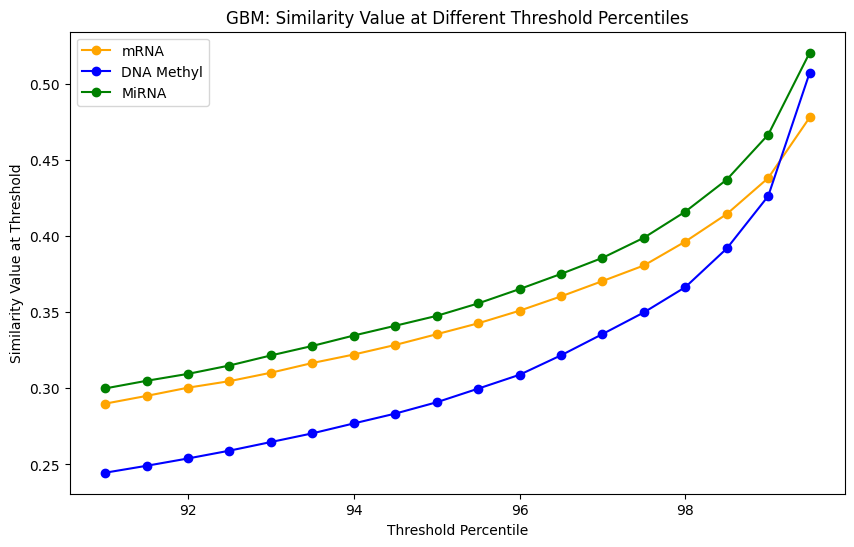

In [61]:
## GBM
features1, features2, features3, labels, indexes = load_data("GBM.mat", type="GBM")
z_fused_fea1 = get_percentile_threshold(features1, method='corr', threshold_pct=97.5)
z_fused_fea2 = get_percentile_threshold(features2, method='corr', threshold_pct=98)
z_fused_fea3 = get_percentile_threshold(features3, method='corr', threshold_pct=98)
thresholds = np.arange(91, 100, 0.5)
per_threshold_fea1 = [np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea2 = [np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea3 = [np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold) for threshold in thresholds]
plt.figure(figsize=(10, 6))
plt.plot(thresholds, per_threshold_fea1, label='mRNA', marker='o', color='orange')
plt.plot(thresholds, per_threshold_fea2, label='DNA Methyl', marker='o', color='blue')
plt.plot(thresholds, per_threshold_fea3, label='MiRNA', marker='o', color='green')
plt.xlabel('Threshold Percentile')
plt.ylabel('Similarity Value at Threshold')
plt.legend()
plt.title('GBM: Similarity Value at Different Threshold Percentiles')
plt.savefig('./images/GBM_similarity_thresholds.png', dpi=300)
deltas_fea1 = [abs((per_threshold_fea1[i] - per_threshold_fea1[0]) - (per_threshold_fea1[-1] - per_threshold_fea1[i])) for i in range(1, len(per_threshold_fea1))]
deltas_fea2 = [abs((per_threshold_fea2[i] - per_threshold_fea2[0]) - (per_threshold_fea2[-1] - per_threshold_fea2[i])) for i in range(1, len(per_threshold_fea2))]
deltas_fea3 = [abs((per_threshold_fea3[i] - per_threshold_fea3[0]) - (per_threshold_fea3[-1] - per_threshold_fea3[i])) for i in range(1, len(per_threshold_fea3))]
deltas_fea1_min = np.argmin(deltas_fea1) + 1
threshold_fea1 = thresholds[deltas_fea1_min]
deltas_fea2_min = np.argmin(deltas_fea2) + 1
threshold_fea2 = thresholds[deltas_fea2_min]
deltas_fea3_min = np.argmin(deltas_fea3) + 1
threshold_fea3 = thresholds[deltas_fea3_min]
print(f"Feature 1: Optimal threshold percentile: {threshold_fea1}, Similarity value: {per_threshold_fea1[deltas_fea1_min]}")
print(f"Feature 2: Optimal threshold percentile: {threshold_fea2}, Similarity value: {per_threshold_fea2[deltas_fea2_min]}")
print(f"Feature 3: Optimal threshold percentile: {threshold_fea3}, Similarity value: {per_threshold_fea3[deltas_fea3_min]}")
ratio_same_label_edges(type='GBM', data_path='GBM.mat', data_edges_dir='./data2/PER_GBM_')

# print("Features 1:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold))
# print("Features 2:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold))
# print("Features 3:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ",np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold))

2026-06-21 08:45:54,946 - INFO - Shape of Gene Expression: (247, 3435)
2026-06-21 08:45:54,947 - INFO - Shape of Methylation Expression: (247, 4741)
2026-06-21 08:45:54,948 - INFO - Shape of miRNA Expression: (247, 102)
2026-06-21 08:45:54,948 - INFO - Shape of labels: (247,)
2026-06-21 08:45:54,949 - INFO - Shape of indexes: (247,)


Percentile threshold (%.1f%%): %.4f 97.5 0.47673869950479086
Percentile threshold (%.1f%%): %.4f 98 0.3759851588334403
Percentile threshold (%.1f%%): %.4f 97.5 0.5308947557755785


2026-06-21 08:45:55,215 - INFO - Shape of Gene Expression: (247, 3435)
2026-06-21 08:45:55,215 - INFO - Shape of Methylation Expression: (247, 4741)
2026-06-21 08:45:55,217 - INFO - Shape of miRNA Expression: (247, 102)
2026-06-21 08:45:55,217 - INFO - Shape of labels: (247,)
2026-06-21 08:45:55,217 - INFO - Shape of indexes: (247,)


Feature 1: Optimal threshold percentile: 97.5, Similarity value: 0.47673869950479086
Feature 2: Optimal threshold percentile: 98.0, Similarity value: 0.3759851588334403
Feature 3: Optimal threshold percentile: 97.5, Similarity value: 0.5308947557755785
Gene edges with same label ratio:  0.5817770232031693
Methylation edges with same label ratio:  0.29254955570745045
MiRNA edges with same label ratio:  0.4538766270514997


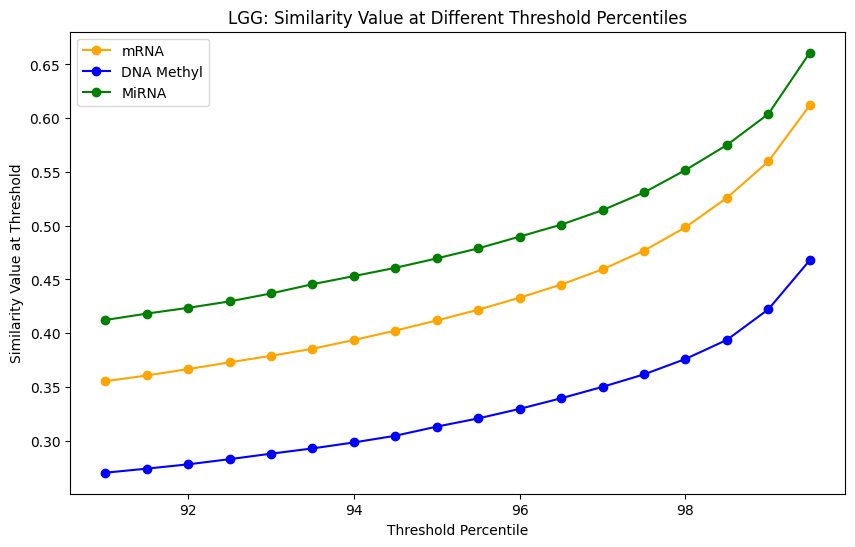

In [55]:
## LGG
features1, features2, features3, labels, indexes = load_data("LGG.mat", type="LGG")
z_fused_fea1 = get_percentile_threshold(features1, method='corr', threshold_pct=97.5)
z_fused_fea2 = get_percentile_threshold(features2, method='corr', threshold_pct=98)
z_fused_fea3 = get_percentile_threshold(features3, method='corr', threshold_pct=97.5)
thresholds = np.arange(91, 100, 0.5)
per_threshold_fea1 = [np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea2 = [np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea3 = [np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold) for threshold in thresholds]
plt.figure(figsize=(10, 6))
plt.plot(thresholds, per_threshold_fea1, label='mRNA', marker='o', color='orange')
plt.plot(thresholds, per_threshold_fea2, label='DNA Methyl', marker='o', color='blue')
plt.plot(thresholds, per_threshold_fea3, label='MiRNA', marker='o', color='green')
plt.xlabel('Threshold Percentile')
plt.ylabel('Similarity Value at Threshold')
plt.legend()
plt.title('LGG: Similarity Value at Different Threshold Percentiles')
plt.savefig('./images/LGG_similarity_thresholds.png', dpi=300)
deltas_fea1 = [abs((per_threshold_fea1[i] - per_threshold_fea1[0]) - (per_threshold_fea1[-1] - per_threshold_fea1[i])) for i in range(1, len(per_threshold_fea1))]
deltas_fea2 = [abs((per_threshold_fea2[i] - per_threshold_fea2[0]) - (per_threshold_fea2[-1] - per_threshold_fea2[i])) for i in range(1, len(per_threshold_fea2))]
deltas_fea3 = [abs((per_threshold_fea3[i] - per_threshold_fea3[0]) - (per_threshold_fea3[-1] - per_threshold_fea3[i])) for i in range(1, len(per_threshold_fea3))]
deltas_fea1_min = np.argmin(deltas_fea1) + 1
threshold_fea1 = thresholds[deltas_fea1_min]
deltas_fea2_min = np.argmin(deltas_fea2) + 1
threshold_fea2 = thresholds[deltas_fea2_min]
deltas_fea3_min = np.argmin(deltas_fea3) + 1
threshold_fea3 = thresholds[deltas_fea3_min]
print(f"Feature 1: Optimal threshold percentile: {threshold_fea1}, Similarity value: {per_threshold_fea1[deltas_fea1_min]}")
print(f"Feature 2: Optimal threshold percentile: {threshold_fea2}, Similarity value: {per_threshold_fea2[deltas_fea2_min]}")
print(f"Feature 3: Optimal threshold percentile: {threshold_fea3}, Similarity value: {per_threshold_fea3[deltas_fea3_min]}")
ratio_same_label_edges(type='LGG', data_path='LGG.mat', data_edges_dir='./data2/PER_LGG_')

# print("Features 1:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold))
# print("Features 2:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold))
# print("Features 3:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ",np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold))

2026-06-21 08:45:33,882 - INFO - Shape of Gene Expression: (284, 3406)
2026-06-21 08:45:33,883 - INFO - Shape of Methylation Expression: (284, 4496)
2026-06-21 08:45:33,883 - INFO - Shape of miRNA Expression: (284, 95)
2026-06-21 08:45:33,884 - INFO - Shape of labels: (284,)
2026-06-21 08:45:33,884 - INFO - Shape of indexes: (284,)


Percentile threshold (%.1f%%): %.4f 97.5 0.2814304090486295
Percentile threshold (%.1f%%): %.4f 98 0.30054747245227925
Percentile threshold (%.1f%%): %.4f 97.5 0.3989973460101582


2026-06-21 08:45:34,157 - INFO - Shape of Gene Expression: (284, 3406)
2026-06-21 08:45:34,157 - INFO - Shape of Methylation Expression: (284, 4496)
2026-06-21 08:45:34,157 - INFO - Shape of miRNA Expression: (284, 95)
2026-06-21 08:45:34,157 - INFO - Shape of labels: (284,)
2026-06-21 08:45:34,157 - INFO - Shape of indexes: (284,)


Feature 1: Optimal threshold percentile: 97.5, Similarity value: 0.2814304090486295
Feature 2: Optimal threshold percentile: 98.0, Similarity value: 0.30054747245227925
Feature 3: Optimal threshold percentile: 97.5, Similarity value: 0.3989973460101582
Gene edges with same label ratio:  0.42894507410636445
Methylation edges with same label ratio:  0.2854122621564482
MiRNA edges with same label ratio:  0.2868352223190933


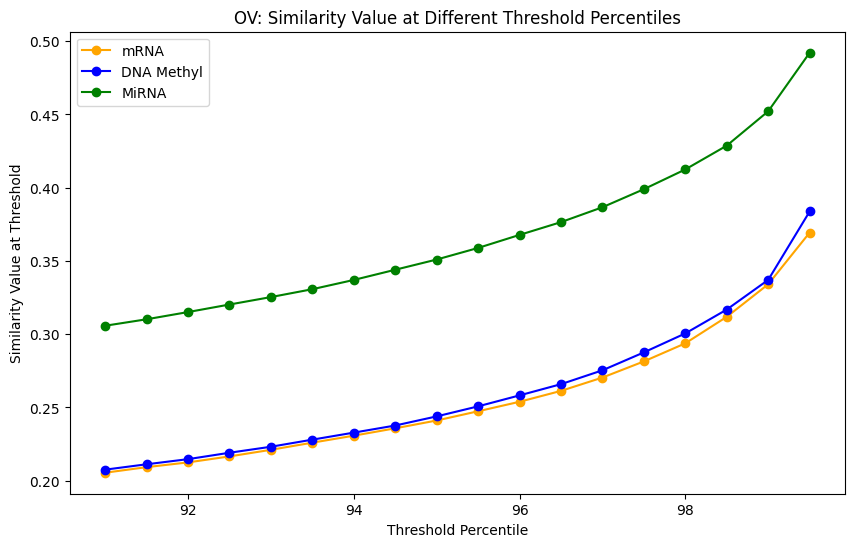

In [54]:
## OV
features1, features2, features3, labels, indexes = load_data("OV.mat", type="OV")
z_fused_fea1 = get_percentile_threshold(features1, method='corr', threshold_pct=97.5)
z_fused_fea2 = get_percentile_threshold(features2, method='corr', threshold_pct=98)
z_fused_fea3 = get_percentile_threshold(features3, method='corr', threshold_pct=97.5)
thresholds = np.arange(91, 100, 0.5)
per_threshold_fea1 = [np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea2 = [np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea3 = [np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold) for threshold in thresholds]
plt.figure(figsize=(10, 6))
plt.plot(thresholds, per_threshold_fea1, label='mRNA', marker='o', color='orange')
plt.plot(thresholds, per_threshold_fea2, label='DNA Methyl', marker='o', color='blue')
plt.plot(thresholds, per_threshold_fea3, label='MiRNA', marker='o', color='green')
plt.xlabel('Threshold Percentile')
plt.ylabel('Similarity Value at Threshold')
plt.legend()
plt.title('OV: Similarity Value at Different Threshold Percentiles')
plt.savefig('./images/OV_similarity_thresholds.png', dpi=300)
deltas_fea1 = [abs((per_threshold_fea1[i] - per_threshold_fea1[0]) - (per_threshold_fea1[-1] - per_threshold_fea1[i])) for i in range(1, len(per_threshold_fea1))]
deltas_fea2 = [abs((per_threshold_fea2[i] - per_threshold_fea2[0]) - (per_threshold_fea2[-1] - per_threshold_fea2[i])) for i in range(1, len(per_threshold_fea2))]
deltas_fea3 = [abs((per_threshold_fea3[i] - per_threshold_fea3[0]) - (per_threshold_fea3[-1] - per_threshold_fea3[i])) for i in range(1, len(per_threshold_fea3))]
deltas_fea1_min = np.argmin(deltas_fea1) + 1
threshold_fea1 = thresholds[deltas_fea1_min]
deltas_fea2_min = np.argmin(deltas_fea2) + 1
threshold_fea2 = thresholds[deltas_fea2_min]
deltas_fea3_min = np.argmin(deltas_fea3) + 1
threshold_fea3 = thresholds[deltas_fea3_min]
print(f"Feature 1: Optimal threshold percentile: {threshold_fea1}, Similarity value: {per_threshold_fea1[deltas_fea1_min]}")
print(f"Feature 2: Optimal threshold percentile: {threshold_fea2}, Similarity value: {per_threshold_fea2[deltas_fea2_min]}")
print(f"Feature 3: Optimal threshold percentile: {threshold_fea3}, Similarity value: {per_threshold_fea3[deltas_fea3_min]}")
ratio_same_label_edges(type='OV', data_path='OV.mat', data_edges_dir='./data2/PER_OV_')
# print("Features 1:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold))
# print("Features 2:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold))
# print("Features 3:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ",np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold))

2026-06-21 08:47:02,815 - INFO - Shape of Gene Expression: (671, 5000)
2026-06-21 08:47:02,815 - INFO - Shape of Methylation Expression: (671, 5000)
2026-06-21 08:47:02,815 - INFO - Shape of miRNA Expression: (671, 200)
2026-06-21 08:47:02,821 - INFO - Shape of labels: (671,)
2026-06-21 08:47:02,821 - INFO - Shape of indexes: (671,)


Percentile threshold (%.1f%%): %.4f 97.5 0.33083088042864267
Percentile threshold (%.1f%%): %.4f 98 0.34112205824874375
Percentile threshold (%.1f%%): %.4f 97.5 0.4121131027348089


2026-06-21 08:47:03,478 - INFO - Shape of Gene Expression: (671, 5000)
2026-06-21 08:47:03,479 - INFO - Shape of Methylation Expression: (671, 5000)
2026-06-21 08:47:03,480 - INFO - Shape of miRNA Expression: (671, 200)
2026-06-21 08:47:03,480 - INFO - Shape of labels: (671,)
2026-06-21 08:47:03,480 - INFO - Shape of indexes: (671,)


Feature 1: Optimal threshold percentile: 97.5, Similarity value: 0.33083088042864267
Feature 2: Optimal threshold percentile: 98.0, Similarity value: 0.34112205824874375
Feature 3: Optimal threshold percentile: 97.5, Similarity value: 0.4121131027348089
Gene edges with same label ratio:  0.5861808412391907
Methylation edges with same label ratio:  0.3909758874055676
MiRNA edges with same label ratio:  0.4698178154646965


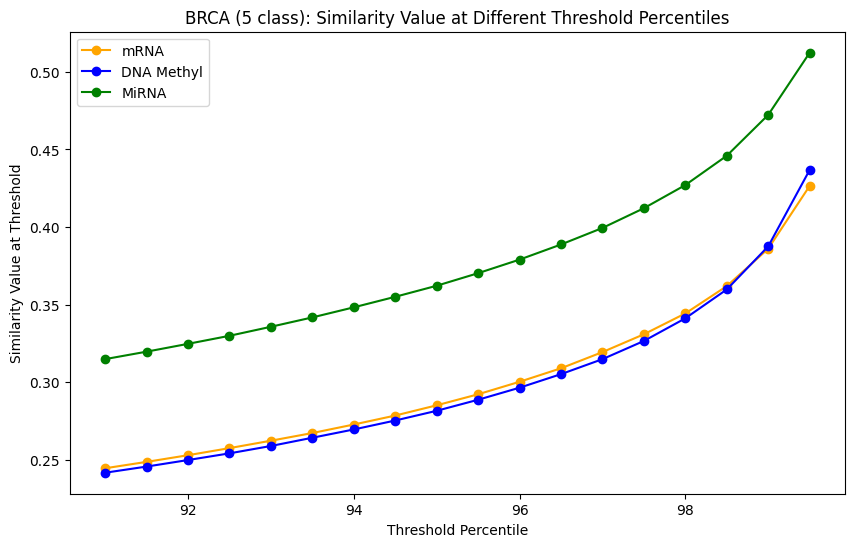

In [59]:
## BRCA_v5
features1, features2, features3, labels, indexes = load_data("BRCA_v5_labels.mat", type="BRCA")
z_fused_fea1 = get_percentile_threshold(features1, type="BRCA_gene", method='corr', threshold_pct=97.5)
z_fused_fea2 = get_percentile_threshold(features2, type="BRCA_gene", method='corr', threshold_pct=98)
z_fused_fea3 = get_percentile_threshold(features3, type="BRCA_gene", method='corr', threshold_pct=97.5)
thresholds = np.arange(91, 100, 0.5)
per_threshold_fea1 = [np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea2 = [np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold) for threshold in thresholds]
per_threshold_fea3 = [np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold) for threshold in thresholds]
plt.figure(figsize=(10, 6))
plt.plot(thresholds, per_threshold_fea1, label='mRNA', marker='o', color='orange')
plt.plot(thresholds, per_threshold_fea2, label='DNA Methyl', marker='o', color='blue')
plt.plot(thresholds, per_threshold_fea3, label='MiRNA', marker='o', color='green')
plt.xlabel('Threshold Percentile')
plt.ylabel('Similarity Value at Threshold')
plt.legend()
plt.title('BRCA (5 class): Similarity Value at Different Threshold Percentiles')
plt.savefig('./images/BRCA_v5_similarity_thresholds.png', dpi=300)
deltas_fea1 = [abs((per_threshold_fea1[i] - per_threshold_fea1[0]) - (per_threshold_fea1[-1] - per_threshold_fea1[i])) for i in range(1, len(per_threshold_fea1))]
deltas_fea2 = [abs((per_threshold_fea2[i] - per_threshold_fea2[0]) - (per_threshold_fea2[-1] - per_threshold_fea2[i])) for i in range(1, len(per_threshold_fea2))]
deltas_fea3 = [abs((per_threshold_fea3[i] - per_threshold_fea3[0]) - (per_threshold_fea3[-1] - per_threshold_fea3[i])) for i in range(1, len(per_threshold_fea3))]
deltas_fea1_min = np.argmin(deltas_fea1) + 1
threshold_fea1 = thresholds[deltas_fea1_min]
deltas_fea2_min = np.argmin(deltas_fea2) + 1
threshold_fea2 = thresholds[deltas_fea2_min]
deltas_fea3_min = np.argmin(deltas_fea3) + 1
threshold_fea3 = thresholds[deltas_fea3_min]
print(f"Feature 1: Optimal threshold percentile: {threshold_fea1}, Similarity value: {per_threshold_fea1[deltas_fea1_min]}")
print(f"Feature 2: Optimal threshold percentile: {threshold_fea2}, Similarity value: {per_threshold_fea2[deltas_fea2_min]}")
print(f"Feature 3: Optimal threshold percentile: {threshold_fea3}, Similarity value: {per_threshold_fea3[deltas_fea3_min]}")
ratio_same_label_edges(type='BRCA', data_path='BRCA_v5_labels.mat', data_edges_dir='./data2/PER_BRCA_v5')
# print("Features 1:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea1[~np.eye(z_fused_fea1.shape[0], dtype=bool)], threshold))
# print("Features 2:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ", np.percentile(z_fused_fea2[~np.eye(z_fused_fea2.shape[0], dtype=bool)], threshold))
# print("Features 3:")
# for threshold in thresholds:
#     # Your code here
#     print(threshold, ": ",np.percentile(z_fused_fea3[~np.eye(z_fused_fea3.shape[0], dtype=bool)], threshold))

In [ ]:
data_BRCA_v5_labels_dir = "./data2/PER_BRCA_v5"
edges_BRCA_v5_gene_path = os.path.join(data_BRCA_v5_labels_dir, 'edges_gene_brca.csv')
edges_BRCA_v5_methy_path = os.path.join(data_BRCA_v5_labels_dir, 'edges_methy_brca.csv')
edges_BRCA_v5_mirna_path = os.path.join(data_BRCA_v5_labels_dir, 'edges_mirna_brca.csv')
data_BRCA_path = './BRCA_v5_labels.mat'
BRCA_features1, BRCA_features2, BRCA_features3, BRCA_labels, BRCA_indexes = load_data(data_BRCA_path, type="BRCA")
edge_gene_set = set()
edge_methy_set = set()
edge_mirna_set = set()
true_edge_gene_set = set()
true_edge_methy_set = set()
true_edge_mirna_set = set()
with open(edges_BRCA_v5_gene_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            if BRCA_labels[node1] == BRCA_labels[node2]:
                true_edge_gene_set.add((node1, node2))
            edge_gene_set.add((node1, node2))
with open(edges_BRCA_v5_methy_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            if BRCA_labels[node1] == BRCA_labels[node2]:
                true_edge_methy_set.add((node1, node2))
            edge_methy_set.add((node1, node2))
with open(edges_BRCA_v5_mirna_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            if BRCA_labels[node1] == BRCA_labels[node2]:
                true_edge_mirna_set.add((node1, node2))
            edge_mirna_set.add((node1, node2))
print(len(edge_gene_set))
print(len(edge_methy_set))
print(len(edge_mirna_set))
print("gene - methy overlap: ", len(edge_gene_set & edge_methy_set))
print("gene - mirna overlap: ", len(edge_gene_set & edge_mirna_set))
print("methy - mirna overlap: ", len(edge_methy_set & edge_mirna_set))
print("gene - methy - mirna overlap: ", len(edge_gene_set & edge_methy_set & edge_mirna_set))
print('true_edge_gene_set: ', len(true_edge_gene_set))
print('true_edge_methy_set: ', len(true_edge_methy_set))
print('true_edge_mirna_set: ', len(true_edge_mirna_set))
print("gene - methy overlap (true edges): ", len(true_edge_gene_set & true_edge_methy_set))
print("gene - mirna overlap (true edges): ", len(true_edge_gene_set & true_edge_mirna_set))
print("methy - mirna overlap (true edges): ", len(true_edge_methy_set & true_edge_mirna_set))
print("gene - methy - mirna overlap (true edges): ", len(true_edge_gene_set & true_edge_methy_set & true_edge_mirna_set))
print("gene - methy union (true edges): ", len(true_edge_gene_set | true_edge_methy_set))
print("gene - mirna union (true edges): ", len(true_edge_gene_set | true_edge_mirna_set))
print("methy - mirna union (true edges): ", len(true_edge_methy_set | true_edge_mirna_set))
print("gene - methy - mirna union (true edges): ", len(true_edge_gene_set | true_edge_methy_set | true_edge_mirna_set))

2026-06-20 20:34:18,694 - INFO - Shape of Gene Expression: (671, 5000)
2026-06-20 20:34:18,694 - INFO - Shape of Methylation Expression: (671, 5000)
2026-06-20 20:34:18,695 - INFO - Shape of miRNA Expression: (671, 200)
2026-06-20 20:34:18,695 - INFO - Shape of labels: (671,)
2026-06-20 20:34:18,695 - INFO - Shape of indexes: (671,)


11240
8992
11240
gene - methy overlap:  1458
gene - mirna overlap:  2560
methy - mirna overlap:  1040
gene - methy - mirna overlap:  530
true_edge_gene_set:  6982
true_edge_methy_set:  3778
true_edge_mirna_set:  5596
gene - methy overlap (true edges):  942
gene - mirna overlap (true edges):  1836
methy - mirna overlap (true edges):  568
gene - methy - mirna overlap (true edges):  348
gene - methy union (true edges):  9818
gene - mirna union (true edges):  10742
methy - mirna union (true edges):  8806
gene - methy - mirna union (true edges):  13358


In [18]:
data_OV_v5_labels_dir = "./data2/PER_OV_"
edges_OV_v5_gene_path = os.path.join(data_OV_v5_labels_dir, 'edges_gene_ov.csv')
edges_OV_v5_methy_path = os.path.join(data_OV_v5_labels_dir, 'edges_methy_ov.csv')
edges_OV_v5_mirna_path = os.path.join(data_OV_v5_labels_dir, 'edges_mirna_ov.csv')
data_OV_path = './OV.mat'
OV_features1, OV_features2, OV_features3, OV_labels, OV_indexes = load_data(data_OV_path, type="OV")
edge_gene_set = set()
edge_methy_set = set()
edge_mirna_set = set()
true_edge_gene_set = set()
true_edge_methy_set = set()
true_edge_mirna_set = set()
false_edge_gene_set = set()
false_edge_methy_set = set()
false_edge_mirna_set = set()
with open(edges_OV_v5_gene_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            edge_gene_set.add((node1, node2))
            if OV_labels[node1] == OV_labels[node2]:
                true_edge_gene_set.add((node1, node2))
            else:
                false_edge_gene_set.add((node1, node2))
with open(edges_OV_v5_methy_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            edge_methy_set.add((node1, node2))
            if OV_labels[node1] == OV_labels[node2]:
                true_edge_methy_set.add((node1, node2))
            else:
                false_edge_methy_set.add((node1, node2))
with open(edges_OV_v5_mirna_path, 'r') as f:
    lines = f.readlines()
    for line in lines:
        node1, node2 = map(int, line.strip().split(','))
        if node1 != node2:
            edge_mirna_set.add((node1, node2))
            if OV_labels[node1] == OV_labels[node2]:
                true_edge_mirna_set.add((node1, node2))
            else:
                false_edge_mirna_set.add((node1, node2))
print(len(edge_gene_set))
print(len(edge_methy_set))
print(len(edge_mirna_set))
print("gene - methy overlap: ", len(edge_gene_set & edge_methy_set))
print("gene - mirna overlap: ", len(edge_gene_set & edge_mirna_set))
print("methy - mirna overlap: ", len(edge_methy_set & edge_mirna_set))
print("gene - methy - mirna overlap: ", len(edge_gene_set & edge_methy_set & edge_mirna_set))
print('true edge gene set: ', len(true_edge_gene_set))
print('true edge methy set: ', len(true_edge_methy_set))
print('true edge mirna set: ', len(true_edge_mirna_set))
print("True gene - methy overlap: ", len(true_edge_gene_set & true_edge_methy_set))
print("True gene - mirna overlap: ", len(true_edge_gene_set & true_edge_mirna_set))
print("True methy - mirna overlap: ", len(true_edge_methy_set & true_edge_mirna_set))
print("True gene - methy - mirna overlap: ", len(true_edge_gene_set & true_edge_methy_set & true_edge_mirna_set))
print("True gene - methy union: ", len(true_edge_gene_set | true_edge_methy_set))
print("True gene - mirna union: ", len(true_edge_gene_set | true_edge_mirna_set))
print("True methy - mirna union: ", len(true_edge_methy_set | true_edge_mirna_set))
print("True gene - methy - mirna union: ", len(true_edge_gene_set | true_edge_methy_set | true_edge_mirna_set))
print('false edge gene set: ', len(false_edge_gene_set))
print('false edge methy set: ', len(false_edge_methy_set))
print('false edge mirna set: ', len(false_edge_mirna_set))
print("False gene - methy overlap: ", len(false_edge_gene_set & false_edge_methy_set))
print("False gene - mirna overlap: ", len(false_edge_gene_set & false_edge_mirna_set))
print("False methy - mirna overlap: ", len(false_edge_methy_set & false_edge_mirna_set))
print("False gene - methy - mirna overlap: ", len(false_edge_gene_set & false_edge_methy_set & false_edge_mirna_set))

2026-06-20 20:37:35,645 - INFO - Shape of Gene Expression: (284, 3406)
2026-06-20 20:37:35,646 - INFO - Shape of Methylation Expression: (284, 4496)
2026-06-20 20:37:35,646 - INFO - Shape of miRNA Expression: (284, 95)
2026-06-20 20:37:35,647 - INFO - Shape of labels: (284,)
2026-06-20 20:37:35,647 - INFO - Shape of indexes: (284,)


2010
1608
2010
gene - methy overlap:  192
gene - mirna overlap:  222
methy - mirna overlap:  106
gene - methy - mirna overlap:  50
true edge gene set:  984
true edge methy set:  540
true edge mirna set:  658
True gene - methy overlap:  138
True gene - mirna overlap:  144
True methy - mirna overlap:  60
True gene - methy - mirna overlap:  40
True gene - methy union:  1386
True gene - mirna union:  1498
True methy - mirna union:  1138
True gene - methy - mirna union:  1880
false edge gene set:  1026
false edge methy set:  1068
false edge mirna set:  1352
False gene - methy overlap:  54
False gene - mirna overlap:  78
False methy - mirna overlap:  46
False gene - methy - mirna overlap:  10


In [10]:
data_BRCA_original_v5_path_gene = "./data2/BRCA_v2/BRCA_mRNA_aligned.csv"
genes_df = pd.read_csv(data_BRCA_original_v5_path_gene, header=0)
print(genes_df.shape)
print(genes_df.iloc[:5, :5])
sample_cols = genes_df.columns[1:]

sample_type = pd.Series(sample_cols).str.split(".").str[-1]

print(sample_type.value_counts())

(11343, 672)
     Unnamed: 0  TCGA.3C.AAAU.01  TCGA.3C.AALI.01  TCGA.3C.AALJ.01  \
0        FBXL15         0.806517         0.008469        -1.529268   
1  LOC105372824         0.658390        -1.347314        -0.357091   
2       TMEM41B         0.012981        -0.051182         0.084653   
3          CHUK         0.180961        -0.304748        -2.157297   
4       ZNF518B         0.243034         0.856080         0.700889   

   TCGA.3C.AALK.01  
0         0.387512  
1        -0.780478  
2        -0.565627  
3        -0.319247  
4         0.475732  
01    671
Name: count, dtype: int64


In [9]:
import pandas as pd
import requests
import time

df = pd.read_csv(data_BRCA_original_v5_path_gene)

sample_cols = df.columns[1:]

patients = (
    pd.Series(sample_cols)
    .str.replace(".", "-", regex=False)
    .str.extract(r"(TCGA-[A-Z0-9]{2}-[A-Z0-9]{4})")[0]
    .drop_duplicates()
)

print("Number of patients:", len(patients))

def get_normal_samples(patient_id):

    url = "https://api.gdc.cancer.gov/cases"

    filters = {
        "op": "=",
        "content": {
            "field": "submitter_id",
            "value": patient_id
        }
    }

    params = {
        "filters": str(filters).replace("'", '"'),
        "expand": "samples",
        "size": 1
    }

    try:
        r = requests.get(url, params=params)
        data = r.json()

        hits = data["data"]["hits"]

        if len(hits) == 0:
            return []

        samples = hits[0]["samples"]

        normal_samples = []

        for s in samples:

            if s["sample_type"] == "Solid Tissue Normal":

                normal_samples.append(
                    s["submitter_id"]
                )

        return normal_samples

    except Exception as e:
        print(patient_id, e)
        return []


results = []

for patient in patients:

    normals = get_normal_samples(patient)

    results.append({
        "patient": patient,
        "normal_samples": ";".join(normals),
        "has_normal": len(normals) > 0
    })

    print(patient, normals)

    time.sleep(0.2)

normal_table = pd.DataFrame(results)


normal_table.to_csv(
    "patient_normal_mapping.csv",
    index=False
)

print(normal_table.head())

Number of patients: 671
TCGA-3C-AAAU []
TCGA-3C-AALI []
TCGA-3C-AALJ []
TCGA-3C-AALK []
TCGA-5L-AAT0 []
TCGA-5T-A9QA []
TCGA-A1-A0SB []
TCGA-A1-A0SE []


KeyboardInterrupt: 